# Análisis de Sentimiento — Naive Bayes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Carga del dataset

In [2]:
url = 'https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv'
ruta = '../data/raw/playstore_reviews.csv'
os.makedirs(os.path.dirname(ruta), exist_ok=True)

if not os.path.exists(ruta):
    urllib.request.urlretrieve(url, ruta)

df = pd.read_csv(ruta)
print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (891, 3)


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


## 2. EDA

In [3]:
print(df.info())
print('\nNulos:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB
None

Nulos:
package_name    0
review          0
polarity        0
dtype: int64


Balance de clases (polarity):
polarity
0    584
1    307
Name: count, dtype: int64
0=negativo, 1=positivo


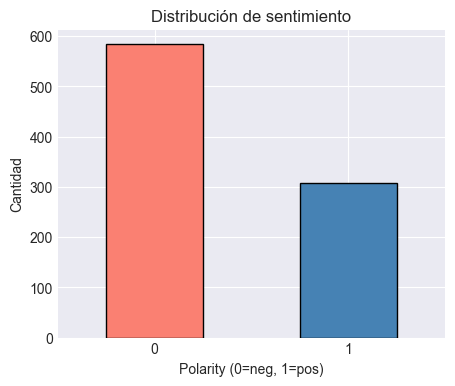

In [4]:
print('Balance de clases (polarity):')
print(df['polarity'].value_counts())
print(f'0=negativo, 1=positivo')

plt.figure(figsize=(5, 4))
df['polarity'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Distribución de sentimiento')
plt.xlabel('Polarity (0=neg, 1=pos)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

In [6]:
# Eliminar filas con review nulo
df = df.dropna(subset=['review'])
print(f'Filas tras eliminar nulos: {len(df)}')

# Limpieza básica del texto
df['review'] = df['review'].str.strip().str.lower()

Filas tras eliminar nulos: 891


<Figure size 800x400 with 0 Axes>

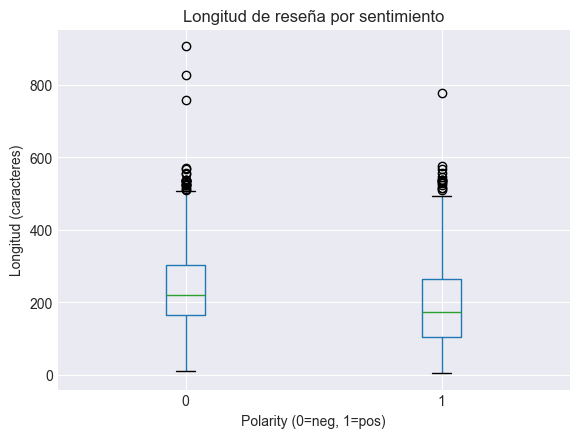

In [7]:
# Longitud promedio de reseñas por sentimiento
df['longitud'] = df['review'].apply(len)

plt.figure(figsize=(8, 4))
df.boxplot(column='longitud', by='polarity')
plt.title('Longitud de reseña por sentimiento')
plt.suptitle('')
plt.xlabel('Polarity (0=neg, 1=pos)')
plt.ylabel('Longitud (caracteres)')
plt.show()

df.drop(columns=['longitud'], inplace=True)

## 3. Vectorización del texto y split

In [9]:
X = df['review']
y = df['polarity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CountVectorizer: convierte texto en matriz de conteos de palabras
# stop_words='english' elimina palabras vacías (the, is, at, etc.)
vec = CountVectorizer(stop_words='english')
X_train_vec = vec.fit_transform(X_train)
X_test_vec  = vec.transform(X_test)

print(f'Train: {X_train_vec.shape[0]} muestras | {X_train_vec.shape[1]} palabras únicas')
print(f'Test:  {X_test_vec.shape[0]} muestras')

Train: 712 muestras | 3310 palabras únicas
Test:  179 muestras


## 4. Comparar las 3 variantes de Naive Bayes

In [10]:
# MultinomialNB: diseñado para conteos de palabras (el más adecuado aquí)
mnb = MultinomialNB()
mnb.fit(X_train_vec, y_train)
acc_mnb = accuracy_score(y_test, mnb.predict(X_test_vec))
print(f'MultinomialNB  -> {acc_mnb:.4f}')

# BernoulliNB: espera variables binarias (presencia/ausencia de palabra)
bnb = BernoulliNB()
bnb.fit(X_train_vec, y_train)
acc_bnb = accuracy_score(y_test, bnb.predict(X_test_vec))
print(f'BernoulliNB    -> {acc_bnb:.4f}')

# GaussianNB: espera features continuas con distribución normal
# Necesita matriz densa, por eso .toarray()
gnb = GaussianNB()
gnb.fit(X_train_vec.toarray(), y_train)
acc_gnb = accuracy_score(y_test, gnb.predict(X_test_vec.toarray()))
print(f'GaussianNB     -> {acc_gnb:.4f}')

MultinomialNB  -> 0.8156
BernoulliNB    -> 0.7709
GaussianNB     -> 0.8045


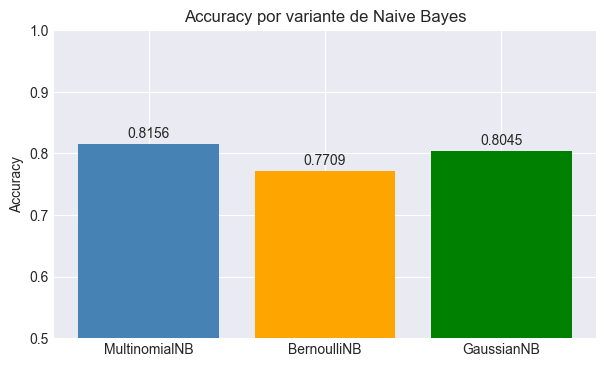

In [11]:
modelos_nb = {'MultinomialNB': acc_mnb, 'BernoulliNB': acc_bnb, 'GaussianNB': acc_gnb}

plt.figure(figsize=(7, 4))
plt.bar(modelos_nb.keys(), modelos_nb.values(), color=['steelblue', 'orange', 'green'])
plt.title('Accuracy por variante de Naive Bayes')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
for i, (nombre, acc) in enumerate(modelos_nb.items()):
    plt.text(i, acc + 0.01, f'{acc:.4f}', ha='center')
plt.show()

## 5. Optimización 

In [12]:
# MultinomialNB es el mejor para texto con conteos
param_dist = {
    'alpha': np.linspace(0.1, 2.0, 20),
    'fit_prior': [True, False]
}

search = RandomizedSearchCV(
    MultinomialNB(),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)
search.fit(X_train_vec, y_train)

print(f'Mejores parámetros: {search.best_params_}')
print(f'Mejor accuracy en CV: {search.best_score_:.4f}')

Mejores parámetros: {'fit_prior': False, 'alpha': np.float64(1.9)}
Mejor accuracy en CV: 0.8202


In [13]:
mnb_opt = search.best_estimator_
y_pred = mnb_opt.predict(X_test_vec)

print(f'Accuracy optimizado en test: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

Accuracy optimizado en test: 0.8212

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.86      0.90      0.88       126
    Positivo       0.72      0.64      0.68        53

    accuracy                           0.82       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.82      0.82      0.82       179



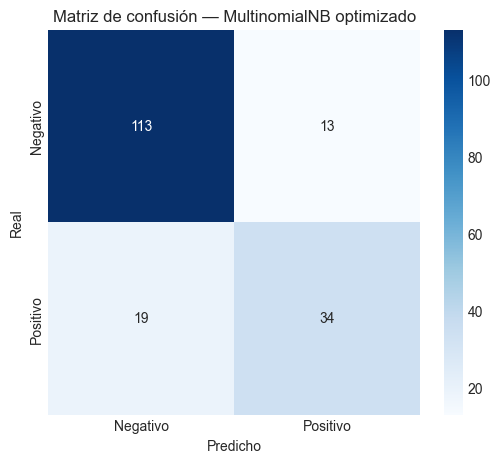

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de confusión — MultinomialNB optimizado')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

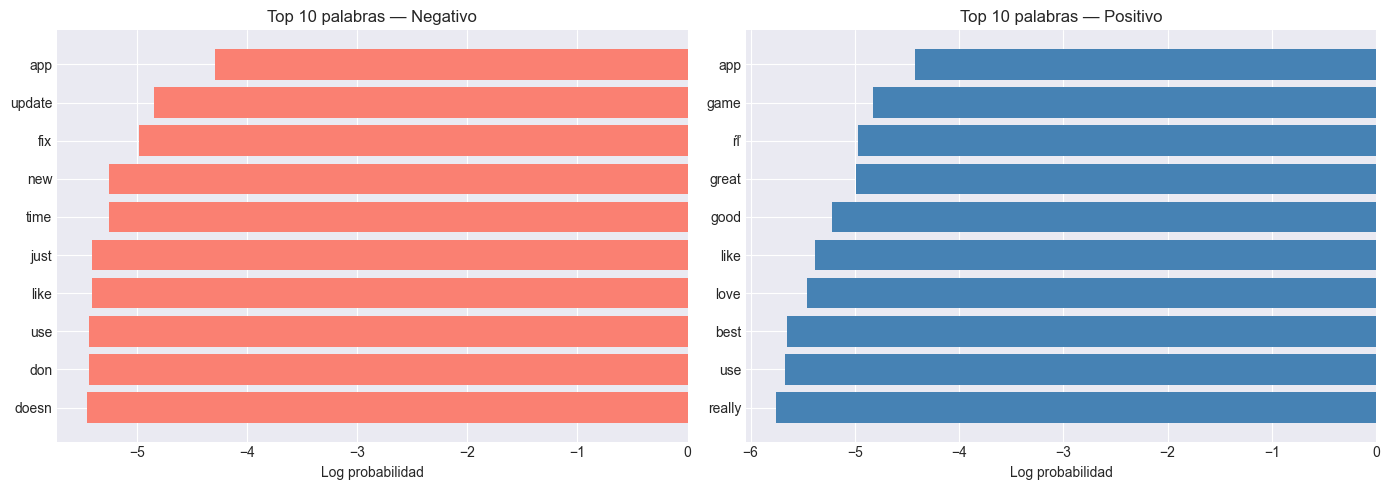

In [15]:
# Palabras más predictoras de cada sentimiento
feature_names = vec.get_feature_names_out()
log_probs = mnb_opt.feature_log_prob_  # shape: (2, n_features)

# Top 10 palabras para negativo (clase 0) y positivo (clase 1)
top_neg = np.argsort(log_probs[0])[-10:][::-1]
top_pos = np.argsort(log_probs[1])[-10:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(feature_names[top_neg][::-1], log_probs[0][top_neg][::-1], color='salmon')
axes[0].set_title('Top 10 palabras — Negativo')
axes[0].set_xlabel('Log probabilidad')

axes[1].barh(feature_names[top_pos][::-1], log_probs[1][top_pos][::-1], color='steelblue')
axes[1].set_title('Top 10 palabras — Positivo')
axes[1].set_xlabel('Log probabilidad')

plt.tight_layout()
plt.show()

## 6. Guardar el modelo y el vectorizador

In [16]:
os.makedirs('../../models', exist_ok=True)
with open('../../models/naive_bayes_sentimiento.pkl', 'wb') as f:
    pickle.dump({'modelo': mnb_opt, 'vectorizador': vec}, f)

print('Modelo y vectorizador guardados en models/naive_bayes_sentimiento.pkl')

# Prueba rápida de predicción
def predecir_sentimiento(texto):
    texto_vec = vec.transform([texto.lower().strip()])
    pred = mnb_opt.predict(texto_vec)[0]
    return 'Positivo' if pred == 1 else 'Negativo'

print(predecir_sentimiento('This app is amazing, I love it!'))
print(predecir_sentimiento('Terrible app, crashes all the time'))

Modelo y vectorizador guardados en models/naive_bayes_sentimiento.pkl
Positivo
Negativo
